# GradCAM Visualisation

This notebook applies Grad-CAM visualisation to the curated and
uncurated binary skin lesion classification models.

This was developed by Kennasa Ahmed and implemented by Gurtej Panesar as part of the group project. It is separate from the main classification notebook to distinguish this contribution from my own work.

## Key Findings and Limitations

The uncurated model assigned a higher malignancy score to both examples than the curated model. Both models assigned a lower malignancy
score to the selected FST V image than to the selected FST I image.

These results are based on one image from each Fitzpatrick skin type (FST) and therefore cannot conclude model performance across skin tones. Evaluation using a larger, balanced set of images would be required.

## Requirements

The trained model files and skin lesion images are not included in
this repository. To produce the visualisation, the file paths in the
configuration cell must be directed to the relevant local files.

In [1]:
# IMPORTS AND CONFIGURATION

from pathlib import Path

import matplotlib.cm as mpl_cm
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from google.colab import drive
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img


# Mount Google Drive
drive.mount("/content/drive")


# Project paths
PROJECT_DIR = Path("/content/drive/MyDrive")
OUTPUT_DIR = PROJECT_DIR / "outputs"

IMG_SIZE = (128, 128)
EPOCHS = 25
MODEL_TAG = f"{EPOCHS}epochs"


# Saved model paths
UNCURATED_MODEL_PATH = (
    OUTPUT_DIR / f"cnn_uncurated_{MODEL_TAG}.keras"
)

CURATED_MODEL_PATH = (
    OUTPUT_DIR / f"cnn_curated_{MODEL_TAG}.keras"
)


# Example Fitzpatrick skin type images
FST_IMAGE_DIR = PROJECT_DIR / "skin_type_examples"

FST1_M = FST_IMAGE_DIR / "FST_1_malignant.jpg"
FST5_M = FST_IMAGE_DIR / "FST_5_malignant.jpg"


# Check that required files exist
required_files = [
    UNCURATED_MODEL_PATH,
    CURATED_MODEL_PATH,
    FST1_M,
    FST5_M,
]

missing_files = [
    file_path
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    print("Missing files:")

    for file_path in missing_files:
        print(f"  {file_path}")

    raise FileNotFoundError(
        "One or more required model or image files could not be found."
    )

print("All required files were found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All required files were found.


In [2]:
# LOAD MODELS

curated_model = load_model(CURATED_MODEL_PATH)
uncurated_model = load_model(UNCURATED_MODEL_PATH)

In [3]:
# BUILD GRAD-CAM COMPONENTS

def build_gradcam_components(model):
    """
    Split a Sequential CNN into:

    1. feature_model:
       Input image -> final convolutional feature maps

    2. classifier_model:
       Final convolutional feature maps -> model prediction
    """

    conv_layer_indices = [
        index
        for index, layer in enumerate(model.layers)
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

    if not conv_layer_indices:
        raise ValueError(
            "No convolutional layer was found in the model."
        )

    last_conv_index = conv_layer_indices[-1]
    last_conv_layer = model.layers[last_conv_index]

    # Image -> final convolutional feature maps
    feature_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=last_conv_layer.output,
        name=f"{model.name}_feature_extractor",
    )

    # Final convolutional feature maps -> prediction
    classifier_input = tf.keras.Input(
        shape=tuple(last_conv_layer.output.shape[1:]),
        name="gradcam_classifier_input",
    )

    x = classifier_input

    for layer in model.layers[last_conv_index + 1:]:
        x = layer(x)

    classifier_model = tf.keras.Model(
        inputs=classifier_input,
        outputs=x,
        name=f"{model.name}_classifier_head",
    )

    print(
        f"Grad-CAM layer for {model.name}: "
        f"{last_conv_layer.name}"
    )

    return feature_model, classifier_model


unc_feature_model, unc_classifier_model = (
    build_gradcam_components(uncurated_model)
)

cur_feature_model, cur_classifier_model = (
    build_gradcam_components(curated_model)
)


# GRAD-CAM FUNCTION

def make_gradcam_heatmap(
    img_array,
    feature_model,
    classifier_model,
):
    """
    Generate a Grad-CAM heatmap for the malignant class.

    This assumes the sigmoid output represents:
    benign = 0
    malignant = 1
    """

    img_array = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        conv_outputs = feature_model(
            img_array,
            training=False,
        )

        # Explicitly watch this intermediate tensor
        tape.watch(conv_outputs)

        predictions = classifier_model(
            conv_outputs,
            training=False,
        )

        # Binary sigmoid output: probability of class 1
        class_channel = predictions[:, 0]

    grads = tape.gradient(
        class_channel,
        conv_outputs,
    )

    if grads is None:
        raise RuntimeError(
            "The prediction is still disconnected from the "
            "convolutional feature maps."
        )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2),
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1,
    )

    heatmap = tf.maximum(heatmap, 0)

    maximum = tf.reduce_max(heatmap)

    heatmap = tf.where(
        maximum > 0,
        heatmap / maximum,
        heatmap,
    )

    malignancy_score = float(predictions[0, 0])

    return heatmap.numpy(), malignancy_score

Grad-CAM layer for sequential: conv2d_3
Grad-CAM layer for sequential_1: conv2d_7


In [4]:
# HEATMAP OVERLAY FUNCTION

def overlay_gradcam(
    img_path,
    feature_model,
    classifier_model,
):
    image = load_img(
        img_path,
        target_size=IMG_SIZE,
    )

    image_array = img_to_array(image) / 255.0

    model_input = np.expand_dims(
        image_array,
        axis=0,
    )

    heatmap, malignancy_score = make_gradcam_heatmap(
        model_input,
        feature_model,
        classifier_model,
    )

    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE,
    )

    heatmap = tf.squeeze(heatmap).numpy()

    coloured_heatmap = mpl_cm.jet(
        heatmap
    )[:, :, :3]

    overlay = np.clip(
        image_array * 0.7
        + coloured_heatmap * 0.3,
        0,
        1,
    )

    return overlay, malignancy_score

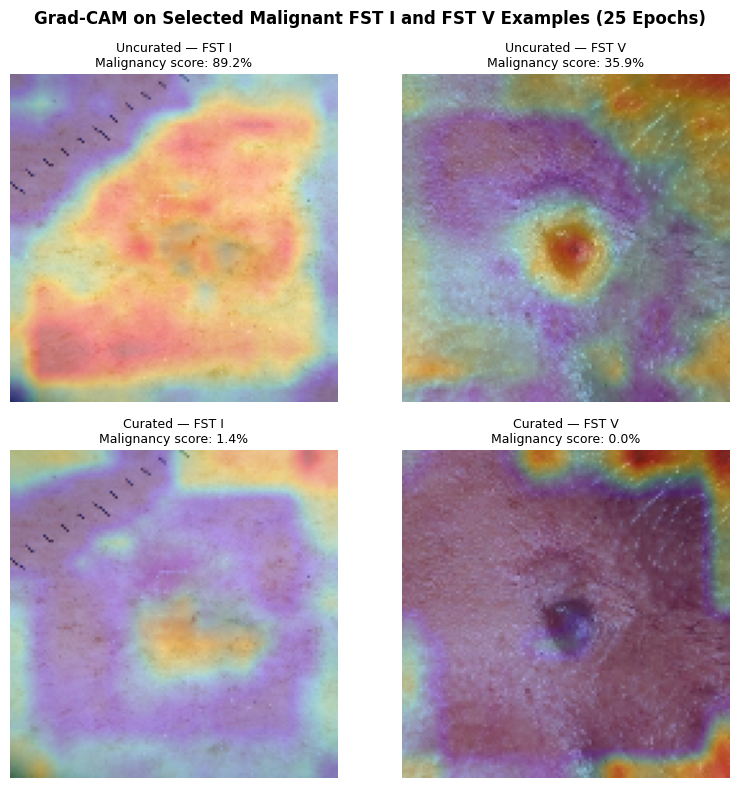

Grad-CAM figure saved to: /content/drive/MyDrive/outputs/gradcam_fst_25epochs.png


In [5]:
# GENERATE GRAD-CAM VISUALISATIONS

# Columns: FST I and FST V
# Rows: Uncurated and Curated

figure, axes = plt.subplots(
    2,
    2,
    figsize=(8, 8),
)

figure.suptitle(
    f"Grad-CAM on Selected Malignant FST I and FST V Examples "
    f"({EPOCHS} Epochs)",
    fontsize=12,
    fontweight="bold",
)


# Uncurated model
img_u1, conf_u1 = overlay_gradcam(
    FST1_M,
    unc_feature_model,
    unc_classifier_model,
)

img_u5, conf_u5 = overlay_gradcam(
    FST5_M,
    unc_feature_model,
    unc_classifier_model,
)

axes[0, 0].imshow(img_u1)
axes[0, 0].set_title(
    f"Uncurated — FST I\n"
    f"Malignancy score: {conf_u1 * 100:.1f}%",
    fontsize=9,
)
axes[0, 0].axis("off")

axes[0, 1].imshow(img_u5)
axes[0, 1].set_title(
    f"Uncurated — FST V\n"
    f"Malignancy score: {conf_u5 * 100:.1f}%",
    fontsize=9,
)
axes[0, 1].axis("off")


# Curated model
img_c1, conf_c1 = overlay_gradcam(
    FST1_M,
    cur_feature_model,
    cur_classifier_model,
)

img_c5, conf_c5 = overlay_gradcam(
    FST5_M,
    cur_feature_model,
    cur_classifier_model,
)

axes[1, 0].imshow(img_c1)
axes[1, 0].set_title(
    f"Curated — FST I\n"
    f"Malignancy score: {conf_c1 * 100:.1f}%",
    fontsize=9,
)
axes[1, 0].axis("off")

axes[1, 1].imshow(img_c5)
axes[1, 1].set_title(
    f"Curated — FST V\n"
    f"Malignancy score: {conf_c5 * 100:.1f}%",
    fontsize=9,
)
axes[1, 1].axis("off")


# Row labels
axes[0, 0].set_ylabel(
    "Uncurated",
    fontsize=11,
    fontweight="bold",
)

axes[1, 0].set_ylabel(
    "Curated",
    fontsize=11,
    fontweight="bold",
)


plt.tight_layout()

GRADCAM_OUTPUT_PATH = (
    OUTPUT_DIR / f"gradcam_fst_{MODEL_TAG}.png"
)

plt.savefig(
    GRADCAM_OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Grad-CAM figure saved to: {GRADCAM_OUTPUT_PATH}")